family         180
dep_clayton     90
dep_frank       90
gaussian        90
Name: experiment, dtype: int64
Index(['run_tag', 'prediction_model', 'experiment', 'seed', 'dgp_copula',
       'true_k_tau', 'assumed_copula', 'assumed_k_tau', 'tau_abs_error',
       'alpha_c_mult', 'alpha_c_used', 'censoring_rate', 'ibs_true',
       'ibs_ipcw', 'ibs_dep_bguw', 'bias_ipcw', 'bias_dep_bguw', 'err_ipcw',
       'err_dep_bguw'],
      dtype='object')


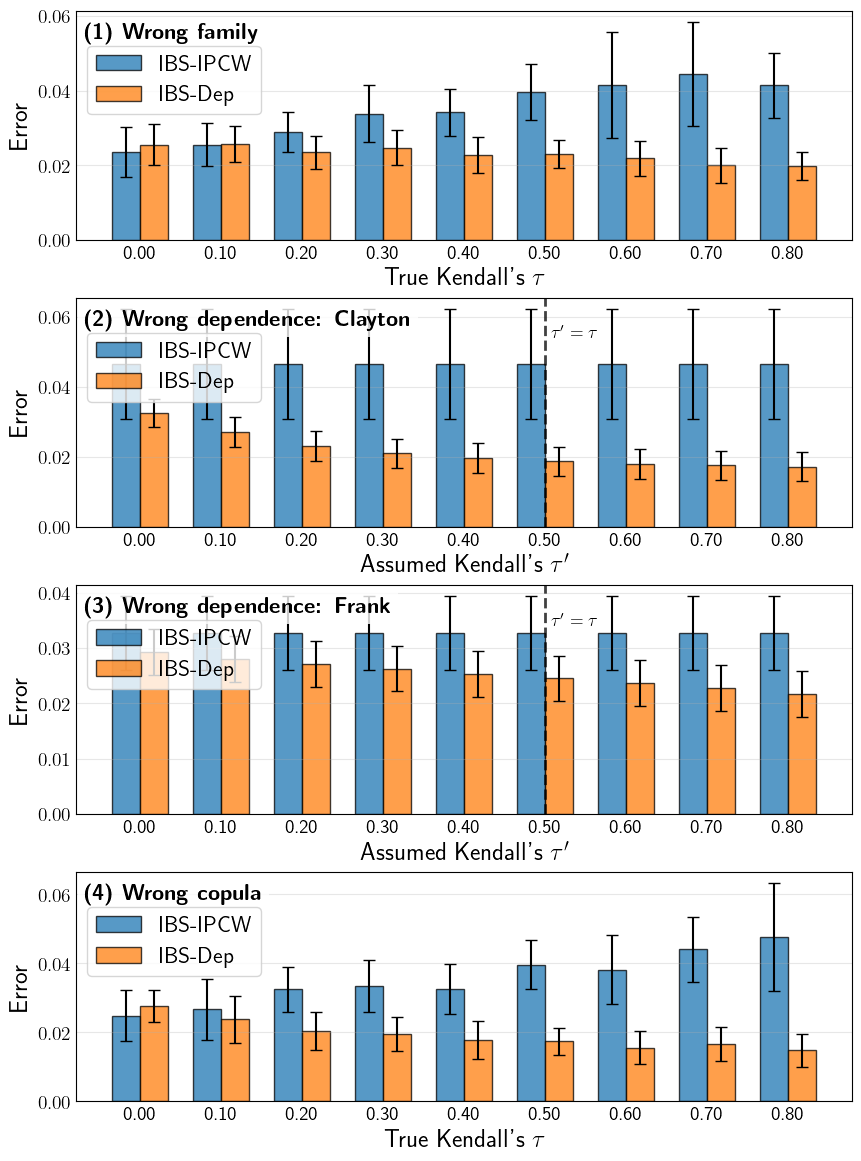

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config as cfg

# --- Matplotlib style ---
plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 16.0,
    "legend.fontsize": "medium",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}"
})

# --- Load data ---
filename = f"{cfg.RESULTS_DIR}/synthetic_results_wrong_copula.csv"
df = pd.read_csv(filename)

print(df["experiment"].value_counts())
print(df.columns)

# New experiment layout:
# family       = wrong family, averaged over Clayton/Frank within seed
# dep_clayton = true Clayton tau=0.5, assumed Clayton tau' varied
# dep_frank   = true Frank tau=0.5, assumed Frank tau' varied
# gaussian    = Gaussian DGP, evaluated with Clayton
keep_exps = ["family", "dep_clayton", "dep_frank", "gaussian"]
dfp = df[df["experiment"].isin(keep_exps)].copy()

# Use assumed_k_tau for the dependence-strength panels.
# Use true_k_tau for family/gaussian panels.
dfp["plot_tau"] = np.where(
    dfp["experiment"].isin(["dep_clayton", "dep_frank"]),
    dfp["assumed_k_tau"],
    dfp["true_k_tau"],
)

# Step 1: average over DGP copulas within seed where relevant.
# For family: average Clayton/Frank within seed.
# For dep_clayton/dep_frank: no averaging across copula family.
# For gaussian: only Gaussian DGP.
seed_level = (
    dfp.groupby(["experiment", "plot_tau", "seed"], as_index=False)
       .agg(
           err_ipcw=("err_ipcw", "mean"),
           err_dep_bguw=("err_dep_bguw", "mean"),
       )
)

# Step 2: mean/std across seeds
agg = (
    seed_level.groupby(["experiment", "plot_tau"], as_index=False)
              .agg(
                  ipcw_mean=("err_ipcw", "mean"),
                  ipcw_std=("err_ipcw", "std"),
                  dep_mean=("err_dep_bguw", "mean"),
                  dep_std=("err_dep_bguw", "std"),
              )
              .sort_values(["experiment", "plot_tau"])
)

agg[["ipcw_std", "dep_std"]] = agg[["ipcw_std", "dep_std"]].fillna(0.0)

exp_order = ["family", "dep_clayton", "dep_frank", "gaussian"]

label_map = {
    "family": r"\textbf{(1) Wrong family}",
    "dep_clayton": r"\textbf{(2) Wrong dependence: Clayton}",
    "dep_frank": r"\textbf{(3) Wrong dependence: Frank}",
    "gaussian": r"\textbf{(4) Wrong copula}",
}

xlabel_map = {
    "family": r"True Kendall's $\tau$",
    "dep_clayton": r"Assumed Kendall's $\tau'$",
    "dep_frank": r"Assumed Kendall's $\tau'$",
    "gaussian": r"True Kendall's $\tau$",
}

# --- Plot ---
fig, axs = plt.subplots(4, 1, figsize=(8.5, 11.5), constrained_layout=True)

bar_width = 0.35
color_ipcw = "C0"
color_dep  = "C1"

for i, exp in enumerate(exp_order):
    ax = axs[i]
    sub = agg[agg["experiment"] == exp].copy()

    taus = sub["plot_tau"].values
    x = np.arange(len(taus))

    ipcw_lower = np.minimum(sub["ipcw_std"].values, sub["ipcw_mean"].values)
    dep_lower  = np.minimum(sub["dep_std"].values,  sub["dep_mean"].values)

    ipcw_yerr = np.vstack([ipcw_lower, sub["ipcw_std"].values])
    dep_yerr  = np.vstack([dep_lower,  sub["dep_std"].values])

    ax.bar(
        x - bar_width / 2,
        sub["ipcw_mean"].values,
        bar_width,
        yerr=ipcw_yerr,
        capsize=4,
        color=color_ipcw,
        edgecolor="black",
        linewidth=1,
        alpha=0.75,
        label=r"IBS-IPCW",
    )

    ax.bar(
        x + bar_width / 2,
        sub["dep_mean"].values,
        bar_width,
        yerr=dep_yerr,
        capsize=4,
        color=color_dep,
        edgecolor="black",
        linewidth=1,
        alpha=0.75,
        label=r"IBS-Dep",
    )

    ax.text(
        0.01, 0.95,
        label_map[exp],
        transform=ax.transAxes,
        fontsize=16,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
    )

    # Mark true tau = 0.5 in the wrong-dependence panels
    if exp in ["dep_clayton", "dep_frank"]:
        true_tau = 0.5
        if np.any(np.isclose(taus, true_tau)):
            true_idx = int(np.where(np.isclose(taus, true_tau))[0][0])
            ax.axvline(true_idx, color="black", linestyle="--", linewidth=2, alpha=0.75)
            ax.text(
                true_idx + 0.08,
                ax.get_ylim()[1] * 0.88,
                r"$\tau'=\tau$",
                fontsize=13,
                va="top",
                ha="left",
            )

    ax.set_ylabel(r"Error", fontsize=18)
    ax.set_xlabel(xlabel_map[exp], fontsize=18)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{t:.2f}" for t in taus], fontsize=14)

    ax.tick_params(axis="y", labelsize=14, length=0)
    ax.tick_params(axis="x", length=0)

    ax.grid(axis="y", alpha=0.3)
    ax.legend(
        frameon=True,
        loc="upper left",
        bbox_to_anchor=(0, 0.895),
    )

plt.savefig(
    f"{cfg.PLOTS_DIR}/synthetic_wrong_copula.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()

family         180
dep_clayton     90
dep_frank       90
gaussian        90
Name: experiment, dtype: int64
Index(['run_tag', 'prediction_model', 'experiment', 'seed', 'dgp_copula',
       'true_k_tau', 'assumed_copula', 'assumed_k_tau', 'tau_abs_error',
       'alpha_c_mult', 'alpha_c_used', 'censoring_rate', 'ibs_true',
       'ibs_ipcw', 'ibs_dep_bguw', 'bias_ipcw', 'bias_dep_bguw', 'err_ipcw',
       'err_dep_bguw'],
      dtype='object')


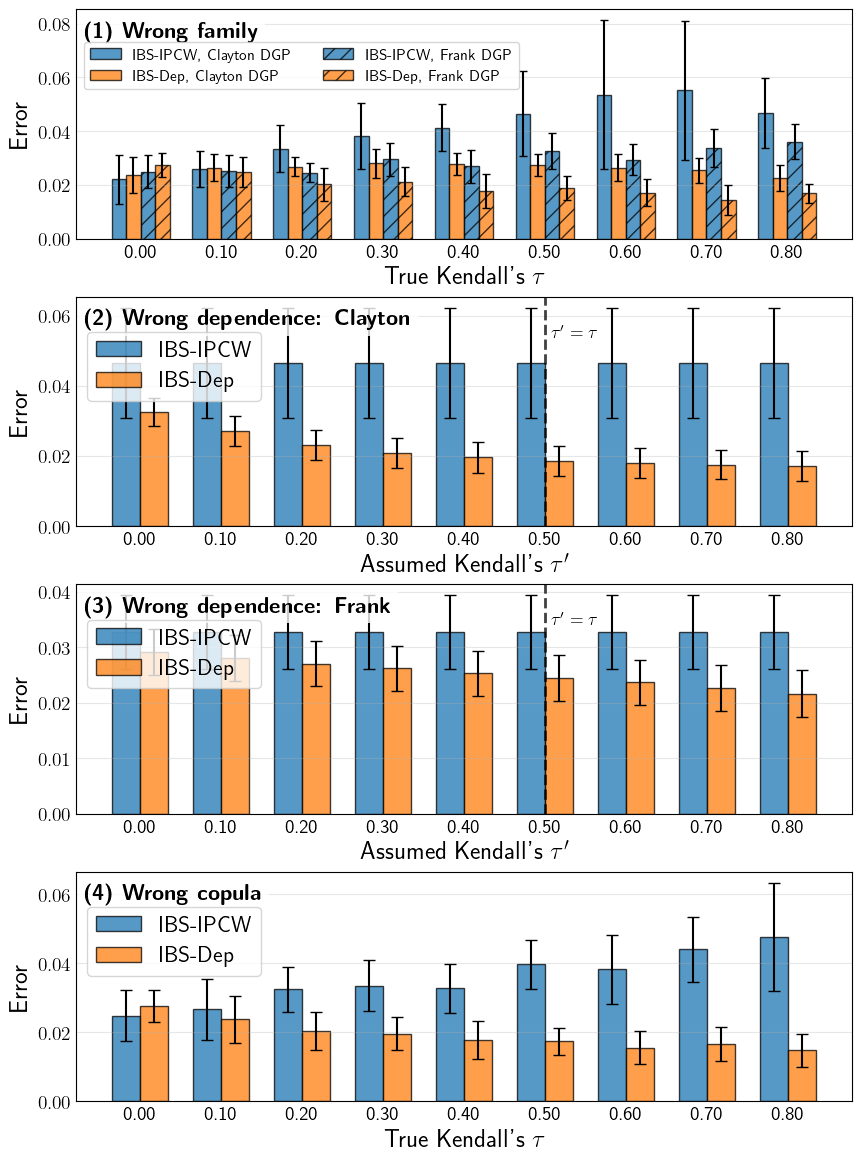

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config as cfg

# --- Matplotlib style ---
plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 16.0,
    "legend.fontsize": "medium",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}"
})

# --- Load data ---
filename = f"{cfg.RESULTS_DIR}/synthetic_results_wrong_copula.csv"
df = pd.read_csv(filename)

print(df["experiment"].value_counts())
print(df.columns)

keep_exps = ["family", "dep_clayton", "dep_frank", "gaussian"]
dfp = df[df["experiment"].isin(keep_exps)].copy()

# Use assumed_k_tau for dependence-strength panels.
# Use true_k_tau for family/gaussian panels.
dfp["plot_tau"] = np.where(
    dfp["experiment"].isin(["dep_clayton", "dep_frank"]),
    dfp["assumed_k_tau"],
    dfp["true_k_tau"],
)

# ---------------------------------------------------------------------
# Aggregation
# ---------------------------------------------------------------------

# Family panel: DO NOT average over Clayton/Frank DGP.
family_seed = (
    dfp[dfp["experiment"] == "family"]
    .groupby(["experiment", "dgp_copula", "plot_tau", "seed"], as_index=False)
    .agg(
        err_ipcw=("err_ipcw", "mean"),
        err_dep_bguw=("err_dep_bguw", "mean"),
    )
)

family_agg = (
    family_seed
    .groupby(["experiment", "dgp_copula", "plot_tau"], as_index=False)
    .agg(
        ipcw_mean=("err_ipcw", "mean"),
        ipcw_std=("err_ipcw", "std"),
        dep_mean=("err_dep_bguw", "mean"),
        dep_std=("err_dep_bguw", "std"),
    )
    .sort_values(["dgp_copula", "plot_tau"])
)

# Other panels: unchanged, since they are already copula-specific.
other_seed = (
    dfp[dfp["experiment"] != "family"]
    .groupby(["experiment", "plot_tau", "seed"], as_index=False)
    .agg(
        err_ipcw=("err_ipcw", "mean"),
        err_dep_bguw=("err_dep_bguw", "mean"),
    )
)

other_agg = (
    other_seed
    .groupby(["experiment", "plot_tau"], as_index=False)
    .agg(
        ipcw_mean=("err_ipcw", "mean"),
        ipcw_std=("err_ipcw", "std"),
        dep_mean=("err_dep_bguw", "mean"),
        dep_std=("err_dep_bguw", "std"),
    )
    .sort_values(["experiment", "plot_tau"])
)

family_agg[["ipcw_std", "dep_std"]] = family_agg[["ipcw_std", "dep_std"]].fillna(0.0)
other_agg[["ipcw_std", "dep_std"]] = other_agg[["ipcw_std", "dep_std"]].fillna(0.0)

exp_order = ["family", "dep_clayton", "dep_frank", "gaussian"]

label_map = {
    "family": r"\textbf{(1) Wrong family}",
    "dep_clayton": r"\textbf{(2) Wrong dependence: Clayton}",
    "dep_frank": r"\textbf{(3) Wrong dependence: Frank}",
    "gaussian": r"\textbf{(4) Wrong copula}",
}

xlabel_map = {
    "family": r"True Kendall's $\tau$",
    "dep_clayton": r"Assumed Kendall's $\tau'$",
    "dep_frank": r"Assumed Kendall's $\tau'$",
    "gaussian": r"True Kendall's $\tau$",
}

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

fig, axs = plt.subplots(4, 1, figsize=(8.5, 11.5), constrained_layout=True)

color_ipcw = "C0"
color_dep = "C1"

for i, exp in enumerate(exp_order):
    ax = axs[i]

    if exp == "family":
        taus = np.sort(family_agg["plot_tau"].unique())
        x = np.arange(len(taus))

        bar_width = 0.18
        offsets = {
            ("clayton", "ipcw"): -1.5 * bar_width,
            ("clayton", "dep"):  -0.5 * bar_width,
            ("frank", "ipcw"):    0.5 * bar_width,
            ("frank", "dep"):     1.5 * bar_width,
        }

        family_specs = [
            ("clayton", "ipcw", color_ipcw, "", r"IBS-IPCW, Clayton DGP"),
            ("clayton", "dep",  color_dep,  "", r"IBS-Dep, Clayton DGP"),
            ("frank",   "ipcw", color_ipcw, "//", r"IBS-IPCW, Frank DGP"),
            ("frank",   "dep",  color_dep,  "//", r"IBS-Dep, Frank DGP"),
        ]

        for dgp_copula, metric, color, hatch, label in family_specs:
            sub = (
                family_agg[family_agg["dgp_copula"] == dgp_copula]
                .set_index("plot_tau")
                .loc[taus]
                .reset_index()
            )

            if metric == "ipcw":
                means = sub["ipcw_mean"].values
                stds = sub["ipcw_std"].values
            else:
                means = sub["dep_mean"].values
                stds = sub["dep_std"].values

            lower = np.minimum(stds, means)
            yerr = np.vstack([lower, stds])

            ax.bar(
                x + offsets[(dgp_copula, metric)],
                means,
                bar_width,
                yerr=yerr,
                capsize=3,
                color=color,
                edgecolor="black",
                linewidth=1,
                alpha=0.75,
                hatch=hatch,
                label=label,
            )

        ax.set_xticks(x)
        ax.set_xticklabels([f"{t:.2f}" for t in taus], fontsize=14)

    else:
        sub = other_agg[other_agg["experiment"] == exp].copy()

        taus = sub["plot_tau"].values
        x = np.arange(len(taus))

        bar_width = 0.35

        ipcw_lower = np.minimum(sub["ipcw_std"].values, sub["ipcw_mean"].values)
        dep_lower = np.minimum(sub["dep_std"].values, sub["dep_mean"].values)

        ipcw_yerr = np.vstack([ipcw_lower, sub["ipcw_std"].values])
        dep_yerr = np.vstack([dep_lower, sub["dep_std"].values])

        ax.bar(
            x - bar_width / 2,
            sub["ipcw_mean"].values,
            bar_width,
            yerr=ipcw_yerr,
            capsize=4,
            color=color_ipcw,
            edgecolor="black",
            linewidth=1,
            alpha=0.75,
            label=r"IBS-IPCW",
        )

        ax.bar(
            x + bar_width / 2,
            sub["dep_mean"].values,
            bar_width,
            yerr=dep_yerr,
            capsize=4,
            color=color_dep,
            edgecolor="black",
            linewidth=1,
            alpha=0.75,
            label=r"IBS-Dep",
        )

        # Mark true tau = 0.5 in the wrong-dependence panels
        if exp in ["dep_clayton", "dep_frank"]:
            true_tau = 0.5
            if np.any(np.isclose(taus, true_tau)):
                true_idx = int(np.where(np.isclose(taus, true_tau))[0][0])
                ax.axvline(true_idx, color="black", linestyle="--", linewidth=2, alpha=0.75)
                ax.text(
                    true_idx + 0.08,
                    ax.get_ylim()[1] * 0.88,
                    r"$\tau'=\tau$",
                    fontsize=13,
                    va="top",
                    ha="left",
                )

        ax.set_xticks(x)
        ax.set_xticklabels([f"{t:.2f}" for t in taus], fontsize=14)

    ax.text(
        0.01, 0.95,
        label_map[exp],
        transform=ax.transAxes,
        fontsize=16,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
    )

    ax.set_ylabel(r"Error", fontsize=18)
    ax.set_xlabel(xlabel_map[exp], fontsize=18)

    ax.tick_params(axis="y", labelsize=14, length=0)
    ax.tick_params(axis="x", length=0)

    ax.grid(axis="y", alpha=0.3)

    if exp == "family":
        ax.legend(
            frameon=True,
            loc="upper left",
            bbox_to_anchor=(0, 0.89),
            fontsize=11,
            ncol=2,
        )
    else:
        ax.legend(
            frameon=True,
            loc="upper left",
            bbox_to_anchor=(0, 0.895),
        )

plt.savefig(
    f"{cfg.PLOTS_DIR}/synthetic_wrong_copula.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()

family         180
dep_clayton     90
dep_frank       90
gaussian        90
Name: experiment, dtype: int64
Index(['run_tag', 'prediction_model', 'experiment', 'seed', 'dgp_copula',
       'true_k_tau', 'assumed_copula', 'assumed_k_tau', 'tau_abs_error',
       'alpha_c_mult', 'alpha_c_used', 'censoring_rate', 'ibs_true',
       'ibs_ipcw', 'ibs_dep_bguw', 'bias_ipcw', 'bias_dep_bguw', 'err_ipcw',
       'err_dep_bguw'],
      dtype='object')


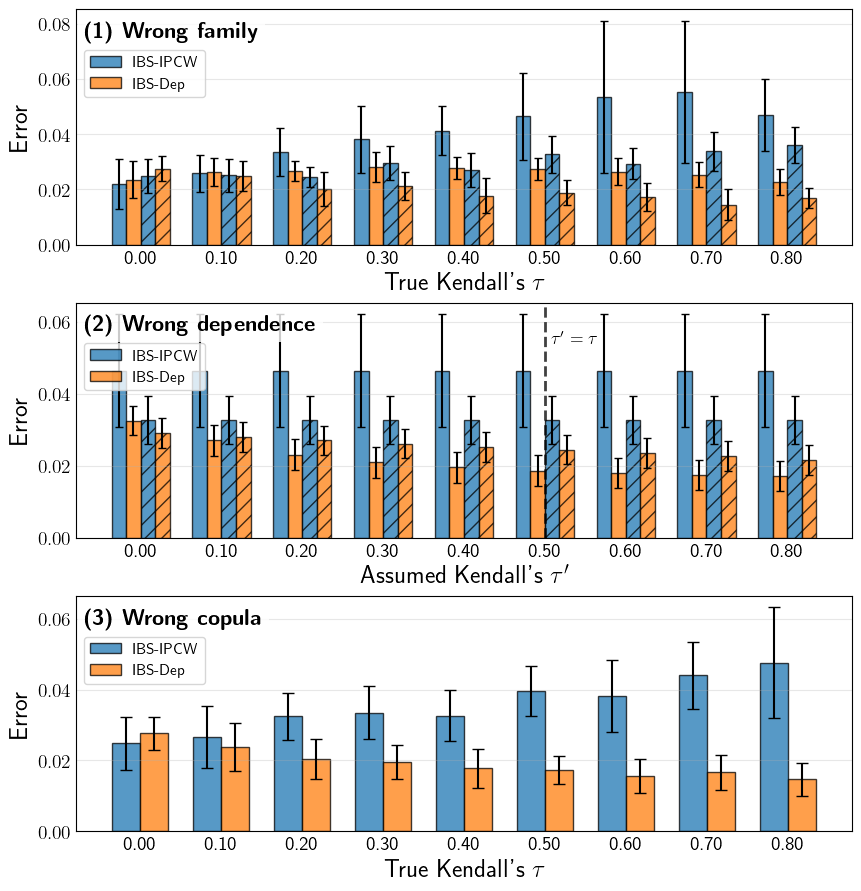

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config as cfg

# --- Matplotlib style ---
plt.style.use("default")
plt.rcParams.update({
    "axes.labelsize": "large",
    "axes.titlesize": "large",
    "font.size": 16.0,
    "legend.fontsize": "medium",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsfonts} \usepackage{amstext} \usepackage{bm}"
})

# --- Load data ---
filename = f"{cfg.RESULTS_DIR}/synthetic_results_wrong_copula.csv"
df = pd.read_csv(filename)

print(df["experiment"].value_counts())
print(df.columns)

keep_exps = ["family", "dep_clayton", "dep_frank", "gaussian"]
dfp = df[df["experiment"].isin(keep_exps)].copy()

# Combine Clayton/Frank wrong-dependence experiments into one panel.
dfp["panel"] = dfp["experiment"].replace({
    "dep_clayton": "dep",
    "dep_frank": "dep",
})

# Use assumed tau for wrong-dependence; true tau otherwise.
dfp["plot_tau"] = np.where(
    dfp["panel"].eq("dep"),
    dfp["assumed_k_tau"],
    dfp["true_k_tau"],
)

# ---------------------------------------------------------------------
# Aggregation
# ---------------------------------------------------------------------

# Keep DGP copula explicit for family and dependence panels.
seed_level = (
    dfp.groupby(["panel", "dgp_copula", "plot_tau", "seed"], as_index=False)
       .agg(
           err_ipcw=("err_ipcw", "mean"),
           err_dep_bguw=("err_dep_bguw", "mean"),
       )
)

agg = (
    seed_level
    .groupby(["panel", "dgp_copula", "plot_tau"], as_index=False)
    .agg(
        ipcw_mean=("err_ipcw", "mean"),
        ipcw_std=("err_ipcw", "std"),
        dep_mean=("err_dep_bguw", "mean"),
        dep_std=("err_dep_bguw", "std"),
    )
    .sort_values(["panel", "dgp_copula", "plot_tau"])
)

agg[["ipcw_std", "dep_std"]] = agg[["ipcw_std", "dep_std"]].fillna(0.0)

panel_order = ["family", "dep", "gaussian"]

label_map = {
    "family": r"\textbf{(1) Wrong family}",
    "dep": r"\textbf{(2) Wrong dependence}",
    "gaussian": r"\textbf{(3) Wrong copula}",
}

xlabel_map = {
    "family": r"True Kendall's $\tau$",
    "dep": r"Assumed Kendall's $\tau'$",
    "gaussian": r"True Kendall's $\tau$",
}

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------

def _yerr_from_mean_std(mean, std):
    lower = np.minimum(std, mean)
    return np.vstack([lower, std])


def plot_four_bar_panel(ax, sub, title, xlabel, mark_true_tau=False):
    taus = np.sort(sub["plot_tau"].unique())
    x = np.arange(len(taus))

    bar_width = 0.18
    color_ipcw = "C0"
    color_dep = "C1"

    offsets = {
        ("clayton", "ipcw"): -1.5 * bar_width,
        ("clayton", "dep"):  -0.5 * bar_width,
        ("frank", "ipcw"):    0.5 * bar_width,
        ("frank", "dep"):     1.5 * bar_width,
    }

    specs = [
        ("clayton", "ipcw", color_ipcw, "",   r"IBS-IPCW"),
        ("clayton", "dep",  color_dep,  "",   r"IBS-Dep"),
        ("frank",   "ipcw", color_ipcw, "//", r"_nolegend_"),
        ("frank",   "dep",  color_dep,  "//", r"_nolegend_"),
    ]

    for dgp_copula, metric, color, hatch, label in specs:
        sub_dgp = sub[sub["dgp_copula"] == dgp_copula].copy()
        if sub_dgp.empty:
            continue

        sub_dgp = sub_dgp.set_index("plot_tau").loc[taus].reset_index()

        if metric == "ipcw":
            means = sub_dgp["ipcw_mean"].values
            stds = sub_dgp["ipcw_std"].values
        else:
            means = sub_dgp["dep_mean"].values
            stds = sub_dgp["dep_std"].values

        ax.bar(
            x + offsets[(dgp_copula, metric)],
            means,
            bar_width,
            yerr=_yerr_from_mean_std(means, stds),
            capsize=3,
            color=color,
            edgecolor="black",
            linewidth=1,
            alpha=0.75,
            hatch=hatch,
            label=label,
        )

    if mark_true_tau:
        true_tau = 0.5
        if np.any(np.isclose(taus, true_tau)):
            true_idx = int(np.where(np.isclose(taus, true_tau))[0][0])
            ax.axvline(true_idx, color="black", linestyle="--", linewidth=2, alpha=0.75)
            ylim_top = ax.get_ylim()[1]
            ax.text(
                true_idx + 0.08,
                ylim_top * 0.88,
                r"$\tau'=\tau$",
                fontsize=13,
                va="top",
                ha="left",
            )

    ax.text(
        0.01, 0.95,
        title,
        transform=ax.transAxes,
        fontsize=16,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
    )

    ax.set_ylabel(r"Error", fontsize=18)
    ax.set_xlabel(xlabel, fontsize=18)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{t:.2f}" for t in taus], fontsize=14)

    ax.tick_params(axis="y", labelsize=14, length=0)
    ax.tick_params(axis="x", length=0)

    ax.grid(axis="y", alpha=0.3)


def plot_two_bar_panel(ax, sub, title, xlabel):
    taus = np.sort(sub["plot_tau"].unique())
    x = np.arange(len(taus))

    sub = sub.set_index("plot_tau").loc[taus].reset_index()

    bar_width = 0.35
    color_ipcw = "C0"
    color_dep = "C1"

    ax.bar(
        x - bar_width / 2,
        sub["ipcw_mean"].values,
        bar_width,
        yerr=_yerr_from_mean_std(sub["ipcw_mean"].values, sub["ipcw_std"].values),
        capsize=4,
        color=color_ipcw,
        edgecolor="black",
        linewidth=1,
        alpha=0.75,
        label=r"IBS-IPCW",
    )

    ax.bar(
        x + bar_width / 2,
        sub["dep_mean"].values,
        bar_width,
        yerr=_yerr_from_mean_std(sub["dep_mean"].values, sub["dep_std"].values),
        capsize=4,
        color=color_dep,
        edgecolor="black",
        linewidth=1,
        alpha=0.75,
        label=r"IBS-Dep",
    )

    ax.text(
        0.01, 0.95,
        title,
        transform=ax.transAxes,
        fontsize=16,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
    )

    ax.set_ylabel(r"Error", fontsize=18)
    ax.set_xlabel(xlabel, fontsize=18)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{t:.2f}" for t in taus], fontsize=14)

    ax.tick_params(axis="y", labelsize=14, length=0)
    ax.tick_params(axis="x", length=0)

    ax.grid(axis="y", alpha=0.3)

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

fig, axs = plt.subplots(3, 1, figsize=(8.5, 8.8), constrained_layout=True)

for i, panel in enumerate(panel_order):
    ax = axs[i]
    sub = agg[agg["panel"] == panel].copy()

    if panel in ["family", "dep"]:
        # Four-bar system:
        # IBS-IPCW, Clayton DGP
        # IBS-Dep, Clayton DGP
        # IBS-IPCW, Frank DGP
        # IBS-Dep, Frank DGP
        plot_four_bar_panel(
            ax,
            sub,
            label_map[panel],
            xlabel_map[panel],
            mark_true_tau=(panel == "dep"),
        )

        ax.legend(
            frameon=True,
            loc="upper left",
            bbox_to_anchor=(0, 0.86),
            fontsize=11,
            ncol=1,
        )

    else:
        # Gaussian DGP -> Clayton working copula. Only one DGP, so two bars.
        sub = sub[sub["dgp_copula"] == "gaussian"].copy()
        plot_two_bar_panel(
            ax,
            sub,
            label_map[panel],
            xlabel_map[panel],
        )

        ax.legend(
            frameon=True,
            loc="upper left",
            bbox_to_anchor=(0, 0.86),
            fontsize=11,
            ncol=1,
        )

plt.savefig(
    f"{cfg.PLOTS_DIR}/synthetic_wrong_copula.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()